---
format: 
    html:
        page-layout: full
        embed-resources: True
        grid:
            body-width: 1200px
        fontsize: 18px
        code-fold: true
        code-summary: "Show the code"
        code-tools: true
        code-copy: false
        number-sections: true

title: Trend Following Trading Strategy Development - Bitcoin
author: Rui Carvalho Caseiro
date: last-modified

warning: False
toc: True
---

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import warnings
warnings.filterwarnings("ignore")

import MyCustomLibrary.main as main
import MyCustomLibrary.backtester as bt
import MyCustomLibrary.backtester_tools as tools
import MyCustomLibrary.features as my_ta

## System Description & Goals

This study will explore the development of a simple trend-following strategy applied to Bitcoin using a moving-average. The core idea is to buy strength when price trades above a simple moving average and exit the trade when it falls below, capturing one of the most robust principles documented in quantitative finance: markets that exhibit momentum tend to continue trending for some time.

**System Goals:**

    - CAGR    > 20%
    - MDD     < 40%
    - Calmar  > 1

## Data

In [2]:
#| code-fold: show

from MyCustomLibrary.data import BTC_Daily

BTC_Daily

BTCUSDT                                     
               Open     High      Low    Close Adj Close
Date                                                    
2010-07-17     0.05     0.05     0.05     0.05       NaN
2010-07-18     0.05     0.09     0.05     0.09       NaN
2010-07-19     0.09     0.09     0.08     0.08       NaN
2010-07-20     0.08     0.08     0.07     0.07       NaN
2010-07-21     0.07     0.08     0.07     0.08       NaN
...             ...      ...      ...      ...       ...
2026-02-14 68856.98 70481.16 68706.62 69767.62       NaN
2026-02-15 69764.95 70939.29 68052.55 68788.19       NaN
2026-02-16 68782.40 70067.23 67301.59 68843.16       NaN
2026-02-17 68843.09 69201.87 66615.28 67494.22       NaN
2026-02-18 67473.45 68332.81 66767.72 66877.57       NaN

[5684 rows x 5 columns]

In [3]:
BTC_Daily.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5684 entries, 2010-07-17 to 2026-02-18
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (BTCUSDT, Open)       5684 non-null   float64
 1   (BTCUSDT, High)       5684 non-null   float64
 2   (BTCUSDT, Low)        5684 non-null   float64
 3   (BTCUSDT, Close)      5684 non-null   float64
 4   (BTCUSDT, Adj Close)  0 non-null      float64
dtypes: float64(5)
memory usage: 266.4 KB


All data is complete, Numbers formatting is correct!

#### Data prep

In [4]:
def df_add_strategy_features(quotes_df: pd.DataFrame, lookbacks: list) -> pd.DataFrame:

    result_df = quotes_df.copy()
    close_series = result_df[('BTCUSDT', 'Close')]

    for lookback in lookbacks:
        result_df.loc[:, ('BTCUSDT', f'SMA{lookback}')] = my_ta.get_SMA(close_series, lookback)
        
    return result_df

In [5]:
lookbacks = [5, 10, 20, 40, 80, 160, 320, 640]

main.timer.start()
screened_df = df_add_strategy_features(BTC_Daily, lookbacks)
main.timer.stop()

screened_df.tail()


[*] Total runtime: 4.54 ms


BTCUSDT                                                         \
               Open     High      Low    Close Adj Close     SMA5    SMA10   
Date                                                                         
2026-02-14 68856.98 70481.16 68706.62 69767.62       NaN 68126.65 68355.82   
2026-02-15 69764.95 70939.29 68052.55 68788.19       NaN 68125.49 68964.43   
2026-02-16 68782.40 70067.23 67301.59 68843.16       NaN 68495.73 68793.21   
2026-02-17 68843.09 69201.87 66615.28 67494.22       NaN 68750.21 68614.43   
2026-02-18 67473.45 68332.81 66767.72 66877.57       NaN 68354.15 68275.72   

                                                                   
              SMA20    SMA40    SMA80   SMA160    SMA320   SMA640  
Date                                                               
2026-02-14 75087.02 83441.93 86389.09 97901.12 101227.58 89101.55  
2026-02-15 74113.07 82818.41 86157.17 97632.77 101170.98 89114.05  
2026-02-16 73100.10 82256.79 85886.22 97371.02 101113.69 89126.62  
2026-02-17 72015.58 81668.46 85588.84 97101.29 101061.00 89136.07  
2026-02-18 71131.38 81077.58 85288.31 96830.37 101011.88 89142.28

## Backtesting

### Signals generation

**Entry:** Buy when price crosses over MA

**Exits:** Exit when price crosses down MA

In [6]:
#| code-fold: show

def symbol_above_SMA(symbol_df: pd.DataFrame, sma_lookback: int, row: int)-> bool:
    """ True if yesterday close is above yesterday SMA value."""
    
    return bool(symbol_df['Close'].iloc[row] > symbol_df[f'SMA{sma_lookback}'].iloc[row])


def symbol_below_SMA(symbol_df: pd.DataFrame, sma_lookback: int, row: int)-> bool:
    """ True if yesterday close is below yesterday SMA value."""

    return bool(symbol_df['Close'].iloc[row] < symbol_df[f'SMA{sma_lookback}'].iloc[row])

### Strategy Implementation

In [7]:
class TrendStrategy(bt.Strategy):
    
    def init(self,
             sma_lookback: int,
             **kwargs
             ):
        
        self.symbol = 'BTCUSDT'
        self.sma_lookback = sma_lookback

    def next(self, i, record):

        try:
            ###------------Buy conditions------------###
            if not self.has_position(self.symbol) and symbol_above_SMA(self.data[self.symbol], self.sma_lookback, row=i-1):
                
                self.open_long(symbol=self.symbol, price=record[(self.symbol,'Open')])
                      
            ###------------Sell conditions------------###
            elif self.has_position(self.symbol) and symbol_below_SMA(self.data[self.symbol], self.sma_lookback, row=i-1):
                
                self.close(symbol=self.symbol, price=record[(self.symbol,'Open')])
            
        except Exception as e:
            import traceback
            print(traceback.format_exc())

In [8]:
#| include: false
# Limited testing to see if everything is working as intended.

lt_backtest = bt.Backtest(TrendStrategy, screened_df.iloc[:500], screened_df[('BTCUSDT', 'Close')].iloc[:500])
lt_result = lt_backtest.run(sma_lookback=40)

lt_result.stats

,Backtest
Start Period,2010-07-17
End Period,2011-12-04
Duration (Months),16
,
CAGR %,3646.70
Ann. Vola %,162.05
Max Drawdown %,-59.56
VaR 5%,-8.66
Time in Market %,52.10
Sharpe,22.50


In [9]:
lt_result.trades

,symbol,open_date,close_date,bars_held,open_price,close_price,position_size,profit_loss,change_pct,trade_commission,cumulative_return,current_open_positions,why_exit
0,BTCUSDT,2010-07-17,2010-08-27,41,0.05,0.06,2017776.20,29237.58,29.27,229.04,129008.54,1,None
1,BTCUSDT,2010-08-28,2010-09-01,4,0.07,0.06,1982764.00,-9913.82,-7.69,247.85,118846.87,1,None
2,BTCUSDT,2010-10-07,2010-11-30,54,0.06,0.23,1890274.57,315845.98,266.02,553.30,434139.55,1,None
3,BTCUSDT,2010-12-03,2010-12-05,2,0.26,0.21,1700807.23,-83339.55,-19.22,784.07,350015.92,1,None
4,BTCUSDT,2010-12-17,2010-12-18,1,0.25,0.24,1398665.03,-13986.65,-4.00,685.35,335343.93,1,None
5,BTCUSDT,2010-12-21,2010-12-22,1,0.27,0.24,1254715.05,-33877.31,-10.11,636.14,300830.48,1,None
6,BTCUSDT,2010-12-23,2011-03-09,75,0.25,0.87,1202119.80,745314.28,248.00,1346.37,1044798.38,1,None
7,BTCUSDT,2011-03-11,2011-03-12,1,0.93,0.88,1118827.99,-59186.00,-5.67,2028.32,983584.06,1,None
8,BTCUSDT,2011-04-13,2011-07-05,78,0.86,13.86,1142559.83,14853277.85,1511.63,16818.48,15820043.43,1,None


### In Sample Optimization Training Data

> It is important that the basic buy-and-sell rules are successful across a range of calculation periods and similar markets. If this fails, then you need to rethink your idea. I don’t believe in adding rules to make the strategy more complex in the hope that one rule will turn a losing idea into a profitable one. It is necessary that the basic concept is robust before moving forward. Then we can try to make it better.
> — Perry Kaufman

In [10]:
#| code-fold: show

df_train, df_test = main.train_test_split(screened_df, test_size=0.20)

optimize = bt.Optimization(TrendStrategy, df_train, df_train[('BTCUSDT', 'Close')], cash=100_000, commission=0.0)

values = [
    lookbacks
    ]

main.timer.start()
optimize.run(values)
main.timer.stop()

Optimization Progress:   0%|          | 0/8 [00:00<?, ?it/s]

Optimization Progress:  12%|█▎        | 1/8 [00:01<00:11,  1.64s/it]

Optimization Progress:  25%|██▌       | 2/8 [00:03<00:09,  1.64s/it]

Optimization Progress:  38%|███▊      | 3/8 [00:04<00:08,  1.64s/it]

Optimization Progress:  50%|█████     | 4/8 [00:06<00:06,  1.67s/it]

...

Optimization Progress:  75%|███████▌  | 6/8 [00:09<00:03,  1.67s/it]

Optimization Progress:  88%|████████▊ | 7/8 [00:11<00:01,  1.66s/it]

Optimization Progress: 100%|██████████| 8/8 [00:13<00:00,  1.66s/it]

Optimization Progress: 100%|██████████| 8/8 [00:13<00:00,  1.66s/it]


[*] Total runtime: 13.30 s


In [11]:
main.plot_comparative_graph(optimize.equity_curves())

Visually inspection on the "optimized" strategy equity curves do reveal that the 2 latest tested lookbacks (320 & 640) do underperfom heavily vs shorter lookbacks.
Lookbacks to 80 days have overperformed the Benchmark in returns terms.

In [12]:
strats_performance =  pd.concat([tools.strategy_performance_metrics(optimize.equity_curves(), steps_per_year=365, rf=0), 
                                 optimize.optimization_trades_stats()], 
                                 axis='index').fillna('-')
strats_performance

,Benchmark,5,10,20,40,80,160,320,640
CAGR %,177.49,212.29,210.23,212.03,225.96,222.57,164.46,74.06,53.10
Ann. Vola %,145.21,76.80,73.80,73.70,76.21,80.26,79.04,75.47,74.32
Max Drawdown %,-93.07,-79.09,-62.99,-64.26,-64.91,-70.28,-84.13,-90.43,-97.79
VaR 5%,-6.73,-3.90,-3.88,-3.95,-4.23,-4.55,-4.64,-5.05,-5.05
Time in Market %,99.52,64.28,61.46,58.34,58.25,58.64,60.01,59.81,66.89
Sharpe,1.22,2.76,2.85,2.88,2.96,2.77,2.08,0.98,0.71
Sortino,2.25,3.46,3.28,3.26,3.25,3.04,2.22,0.98,0.70
Calmar,1.91,2.68,3.34,3.30,3.48,3.17,1.95,0.82,0.54
Efficiency,1.78,3.30,3.42,3.63,3.88,3.80,2.74,1.24,0.79
Nr trades,-,539.00,335.00,209.00,125.00,73.00,40.00,36.00,18.00


The results tell a clear story: **trend following works well on Bitcoin**, but only when trades are allowed to run long enough to capture major trends. Short holding periods generate many trades but relatively weak performance due to noise and volatility.

The strongest performance appears around 20–80 bars, where risk-adjusted metrics peak (Sharpe near 3, with strong Sortino and Calmar ratios).

The system operates with a low win rate (~30%), but remains profitable due to the large reward-to-risk asymmetry. Losses average around -5%, while winners range from roughly 20% to over 200%, reflecting the classic trend-following principle: **cut losses short and let profits run**.

As lokback increases, holding periods increase and trade quality improves as expectancy rises sharply.

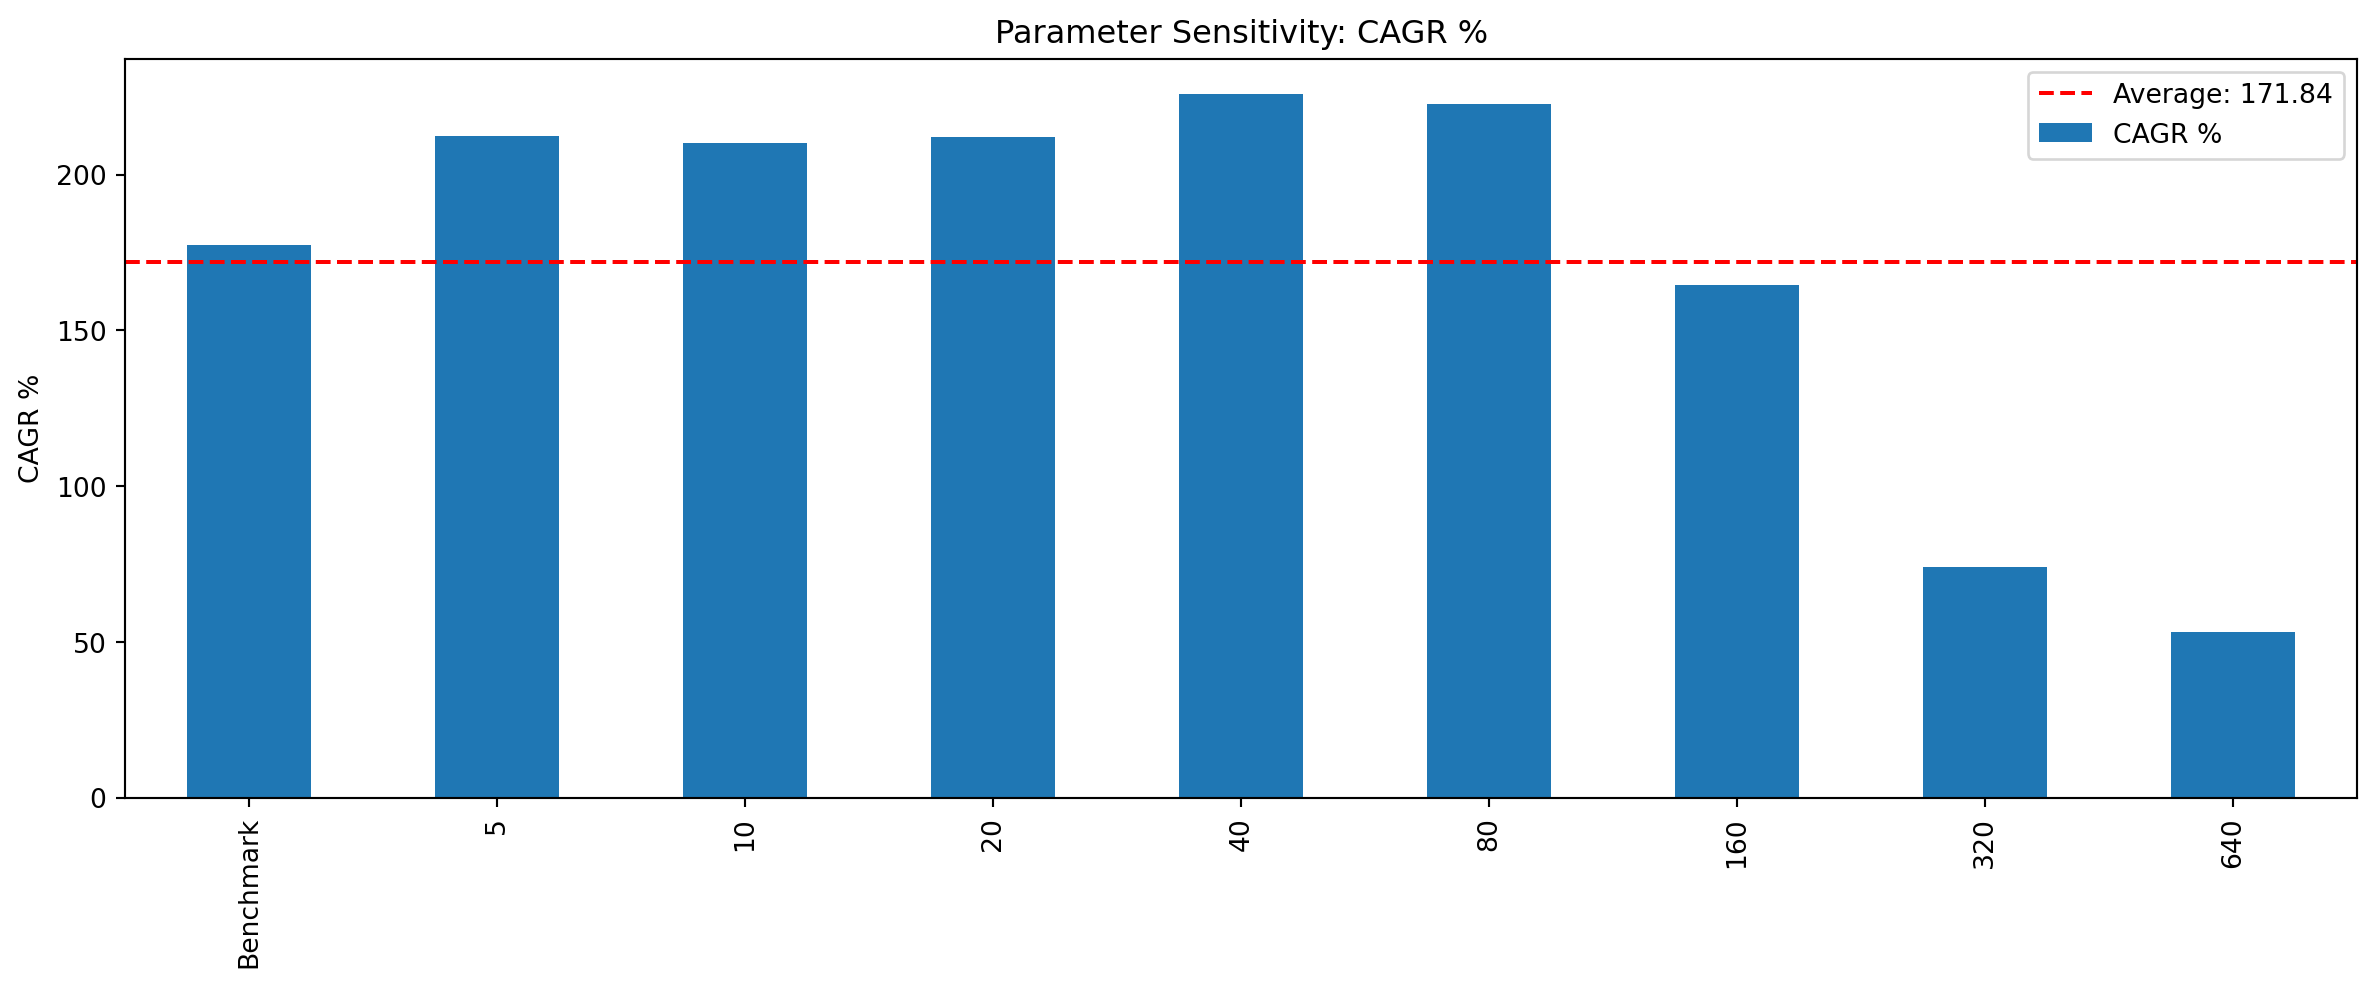

In [13]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'CAGR %')

All lookbacks are profitable, pointing out that these (Entry & Exits) signals are something good to start with.
The goal is not to trade/invest on the highest CAGR strategy, but to choose a strategy parameter that is robust to stand the test of time. 
As stated before, long Lookbacks (160, 320 and 640) have shown to underperform shorter lookbacks.

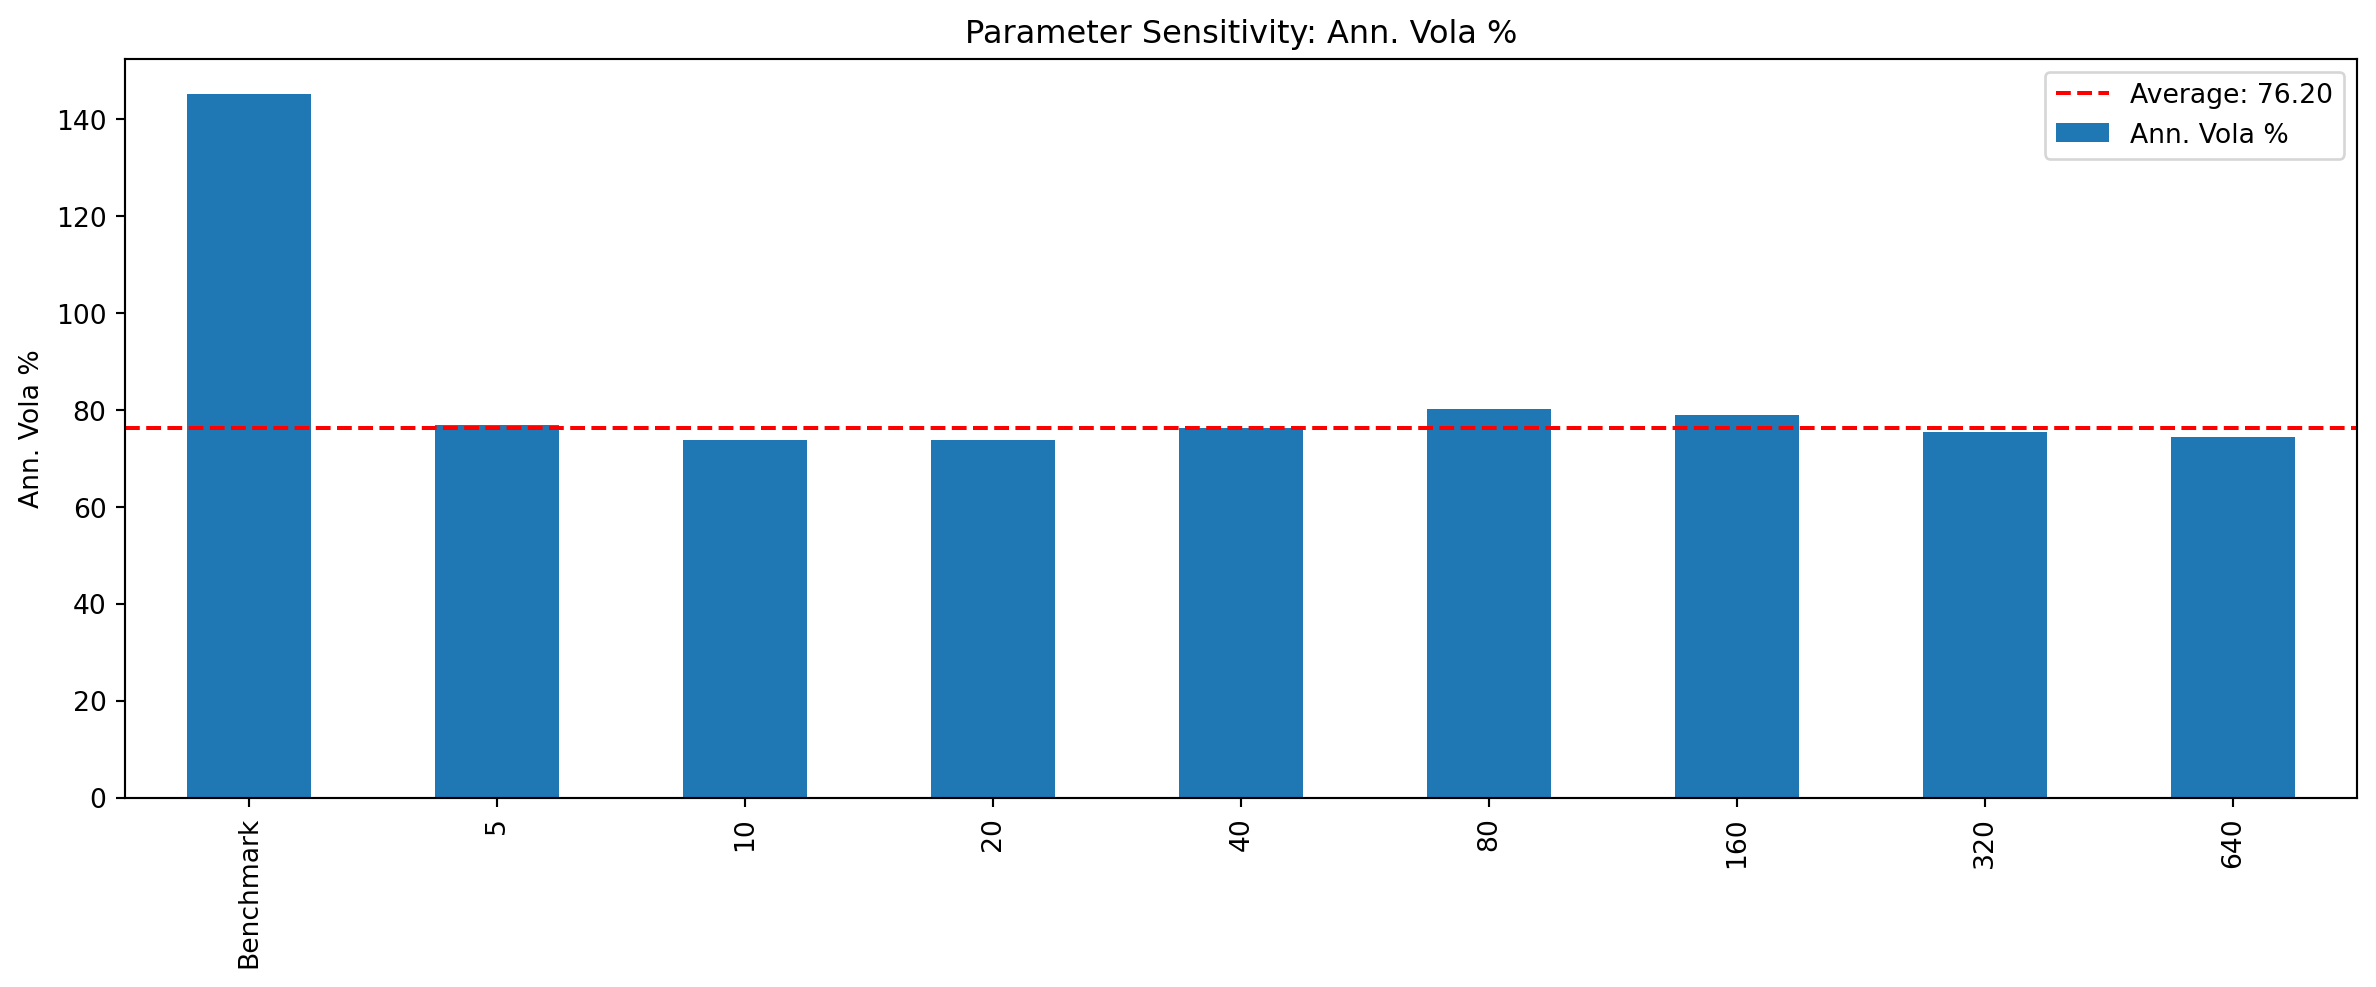

In [14]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'Ann. Vola %')

The trend following filter have managed to cut Bitcoin volatility in half in all of the tested parameters.

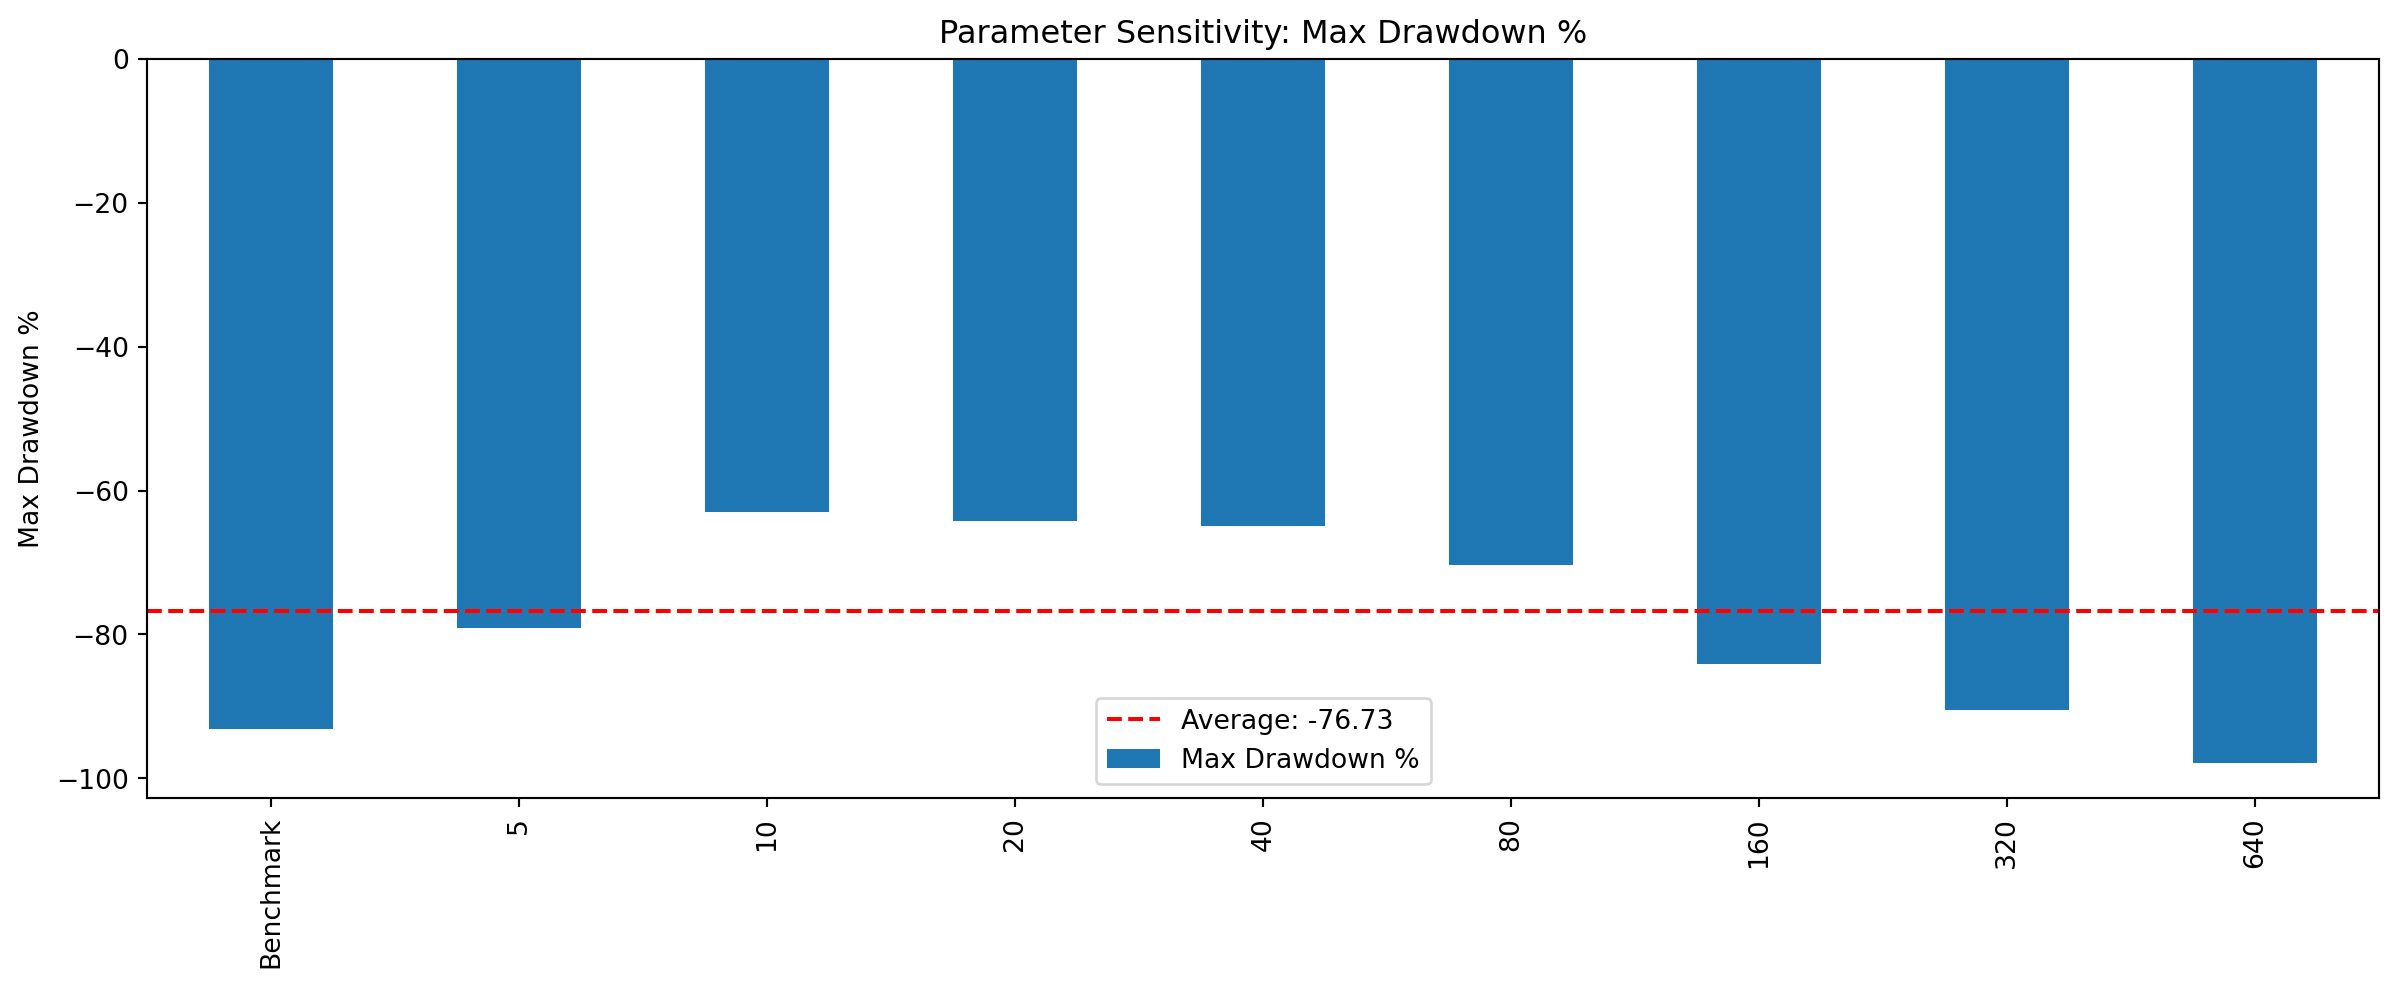

In [15]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'Max Drawdown %')

In terms of Maximum Drawdowns the trend following filter have delivered the best results on the medium-term 20-80 bars lookback horizons.
After 80 bars lookback, the longer the lookback, the longer is the Maximum Drawdown.

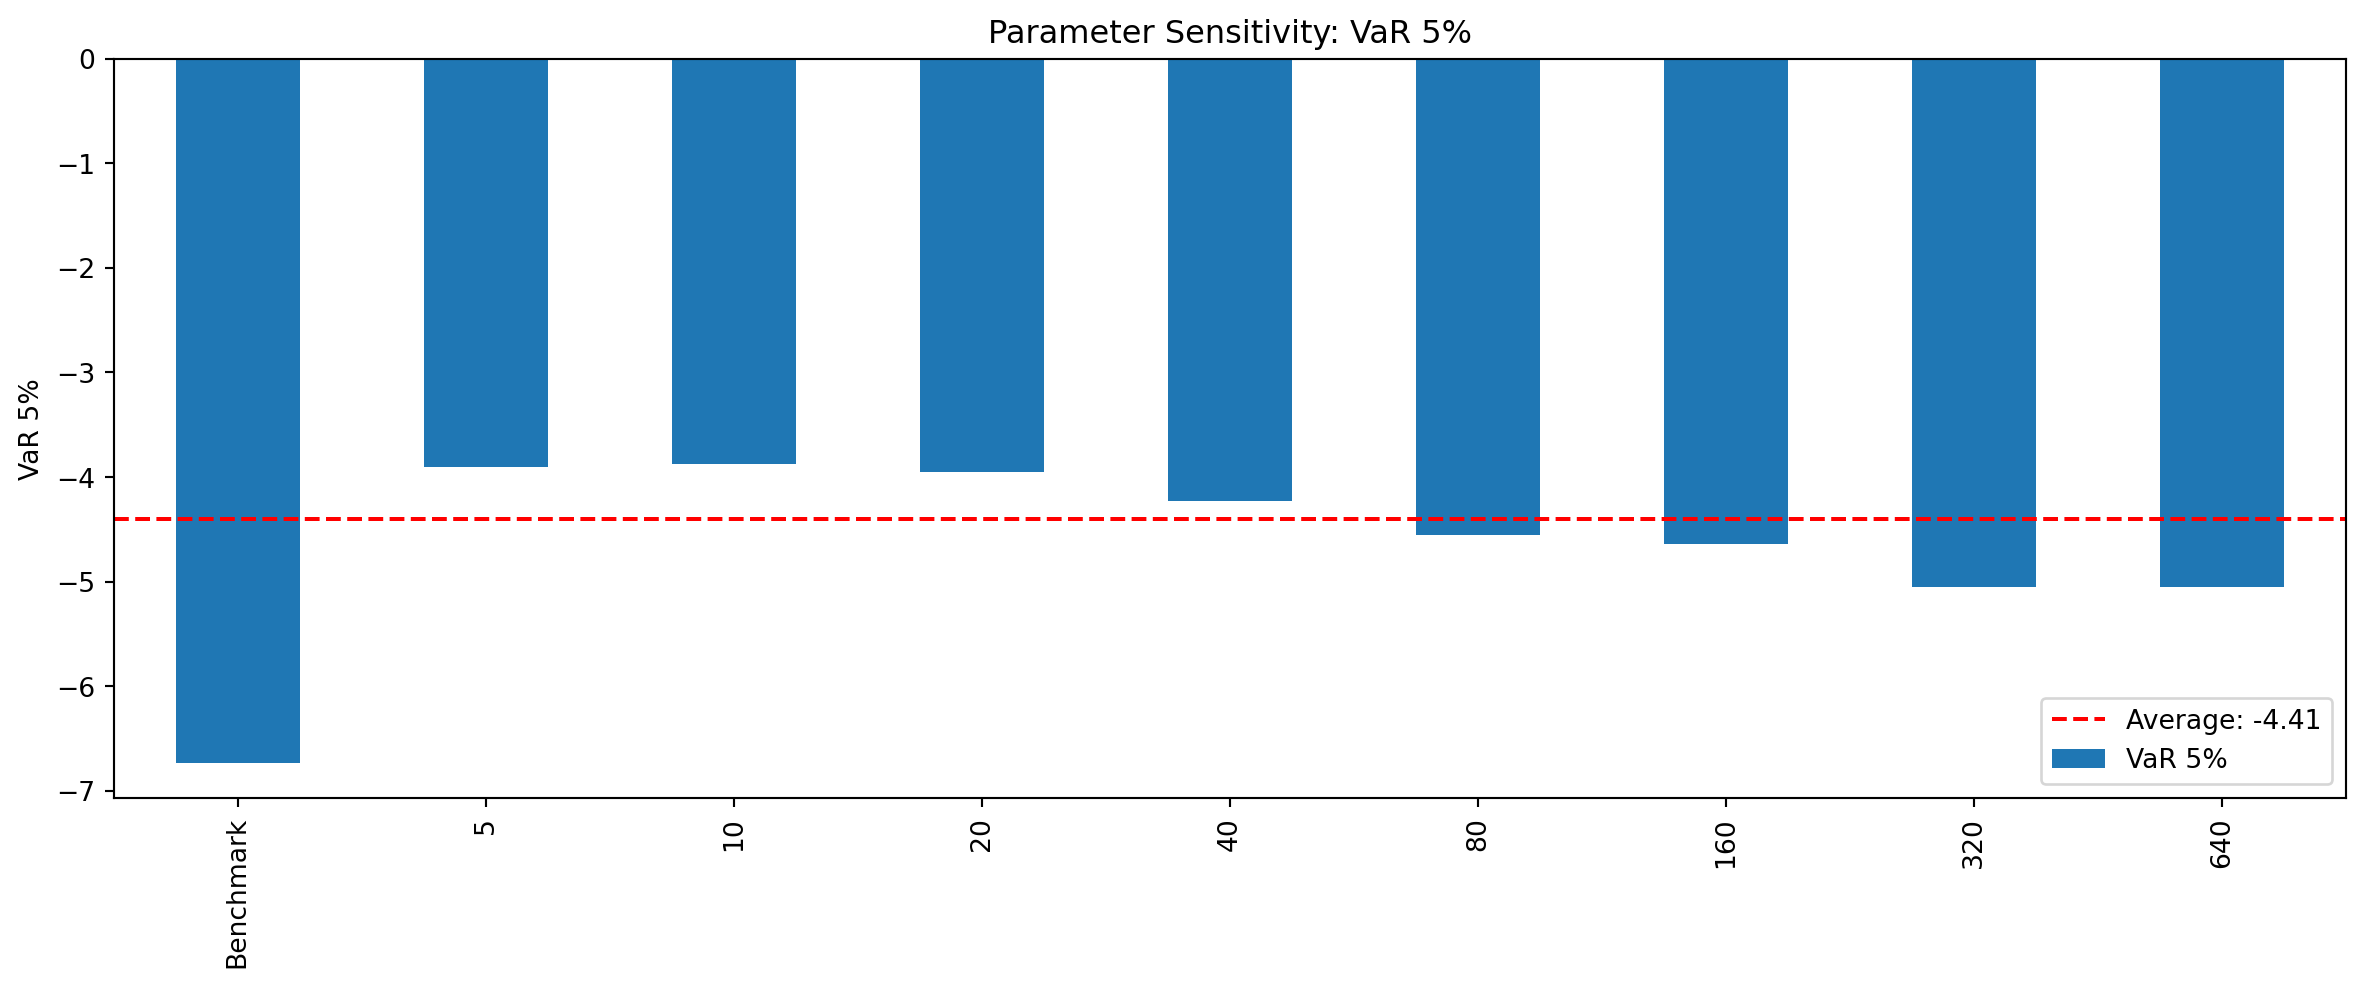

In [16]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'VaR 5%')

All tested parameters managed to deliever a lower historical VAR5% than Bitcoin Buy & Hold, highlighting Trend Following usefullness for more sophisticated investors. VAR has increased with the increase of lookback period, the longer the lokback is, the bigger the VAR is.

**Overall, the results suggest Bitcoin is a highly trend-dominated market, where the strategy’s edge comes from cutting losses quickly and allowing large trends to compound, with the best balance occurring at medium-term holding horizons.**

### Out of Sample Validation

Since we discussed earlier that the most reliable lookback horizon was between 20-80 bars, let's go with the middle figure and test out of sample, including 0.2% cost per trade (Binance Cost Structure).

In [17]:
#| code-fold: show

main.timer.start()
os_backtest = bt.Backtest(TrendStrategy, df_test, df_test[('BTCUSDT', 'Close')], cash=100_000, commission=0.002)
os_result = os_backtest.run(sma_lookback=40)
main.timer.stop()


[*] Total runtime: 362.47 ms


In [18]:
os_result.stats

,Backtest
Start Period,2023-01-03
End Period,2026-02-18
Duration (Months),37
,
CAGR %,56.80
Ann. Vola %,35.02
Max Drawdown %,-24.01
VaR 5%,-2.41
Time in Market %,60.30
Sharpe,1.62


The Out of Sample period spans 37 months from january 2023 until february 2026.
In this period, the Trend Following strategy using 40 days lookback managed to deliver a 56% annualized returns figure with roughly 35% annualized volatility leading to a whoping 1.6 raw Sharpe Ratio, 2.1 raw Sortino Ratio and 2.4 Calmar Ratio. Its only been invested ~60% of the time, with a total of 36 trades averaging ~1 trade per month. Consistent with previous In Sample results, its win rate is around 30% with Huge wins and short losses, boosting the Reward/Risk Ratio to ~7.

In [19]:
main.plot_strategy_performance(os_result.returns, os_result.benchmark)

Trend Following Strategy has been trailing Buy & Hold for most of the time until just recently due to the recent fall Bitcoin has taken since 10/10 Trump Tariffs first announcement. Highlighting once again the superiorness of Wealth preservation vs Buy & Hold.

##### Returns Analysis

In [20]:
tools.strategy_performance_metrics(pd.concat([os_result.returns, os_result.benchmark], axis=1), steps_per_year=365, rf=0)

,Strategy Backtest,Benchmark
CAGR %,56.80,55.86
Ann. Vola %,35.02,47.97
Max Drawdown %,-24.01,-49.74
VaR 5%,-2.41,-3.68
Time in Market %,60.30,100.00
Sharpe,1.62,1.16
Sortino,2.09,1.78
Calmar,2.37,1.12
Efficiency,0.94,0.56


In the out of sample period, Strategy has outperformed Bitcoin Buy & Hold in all fronts like returns, volatility, Maximum Drawdown and Risk Adjusted Returns.

In [21]:
tools.metrics_time_window_analysis(pd.concat([os_result.returns, os_result.benchmark], axis=1), lookbacks=[3, 6, 9, 12, 18, 24])

,Strategy Backtest,Benchmark
3-month,48.6%,62.9%
6-month,75.0%,78.1%
9-month,96.6%,93.1%
12-month,92.3%,84.6%
18-month,100.0%,100.0%
24-month,100.0%,100.0%


Up until 9 months, BH proved to be more reliable in terms of wealth preservation than the trend following strategy.
On a 12 month rolling scenario, trading strategy delivered a profit 100% of the time vs Buy & Hold ~85%.

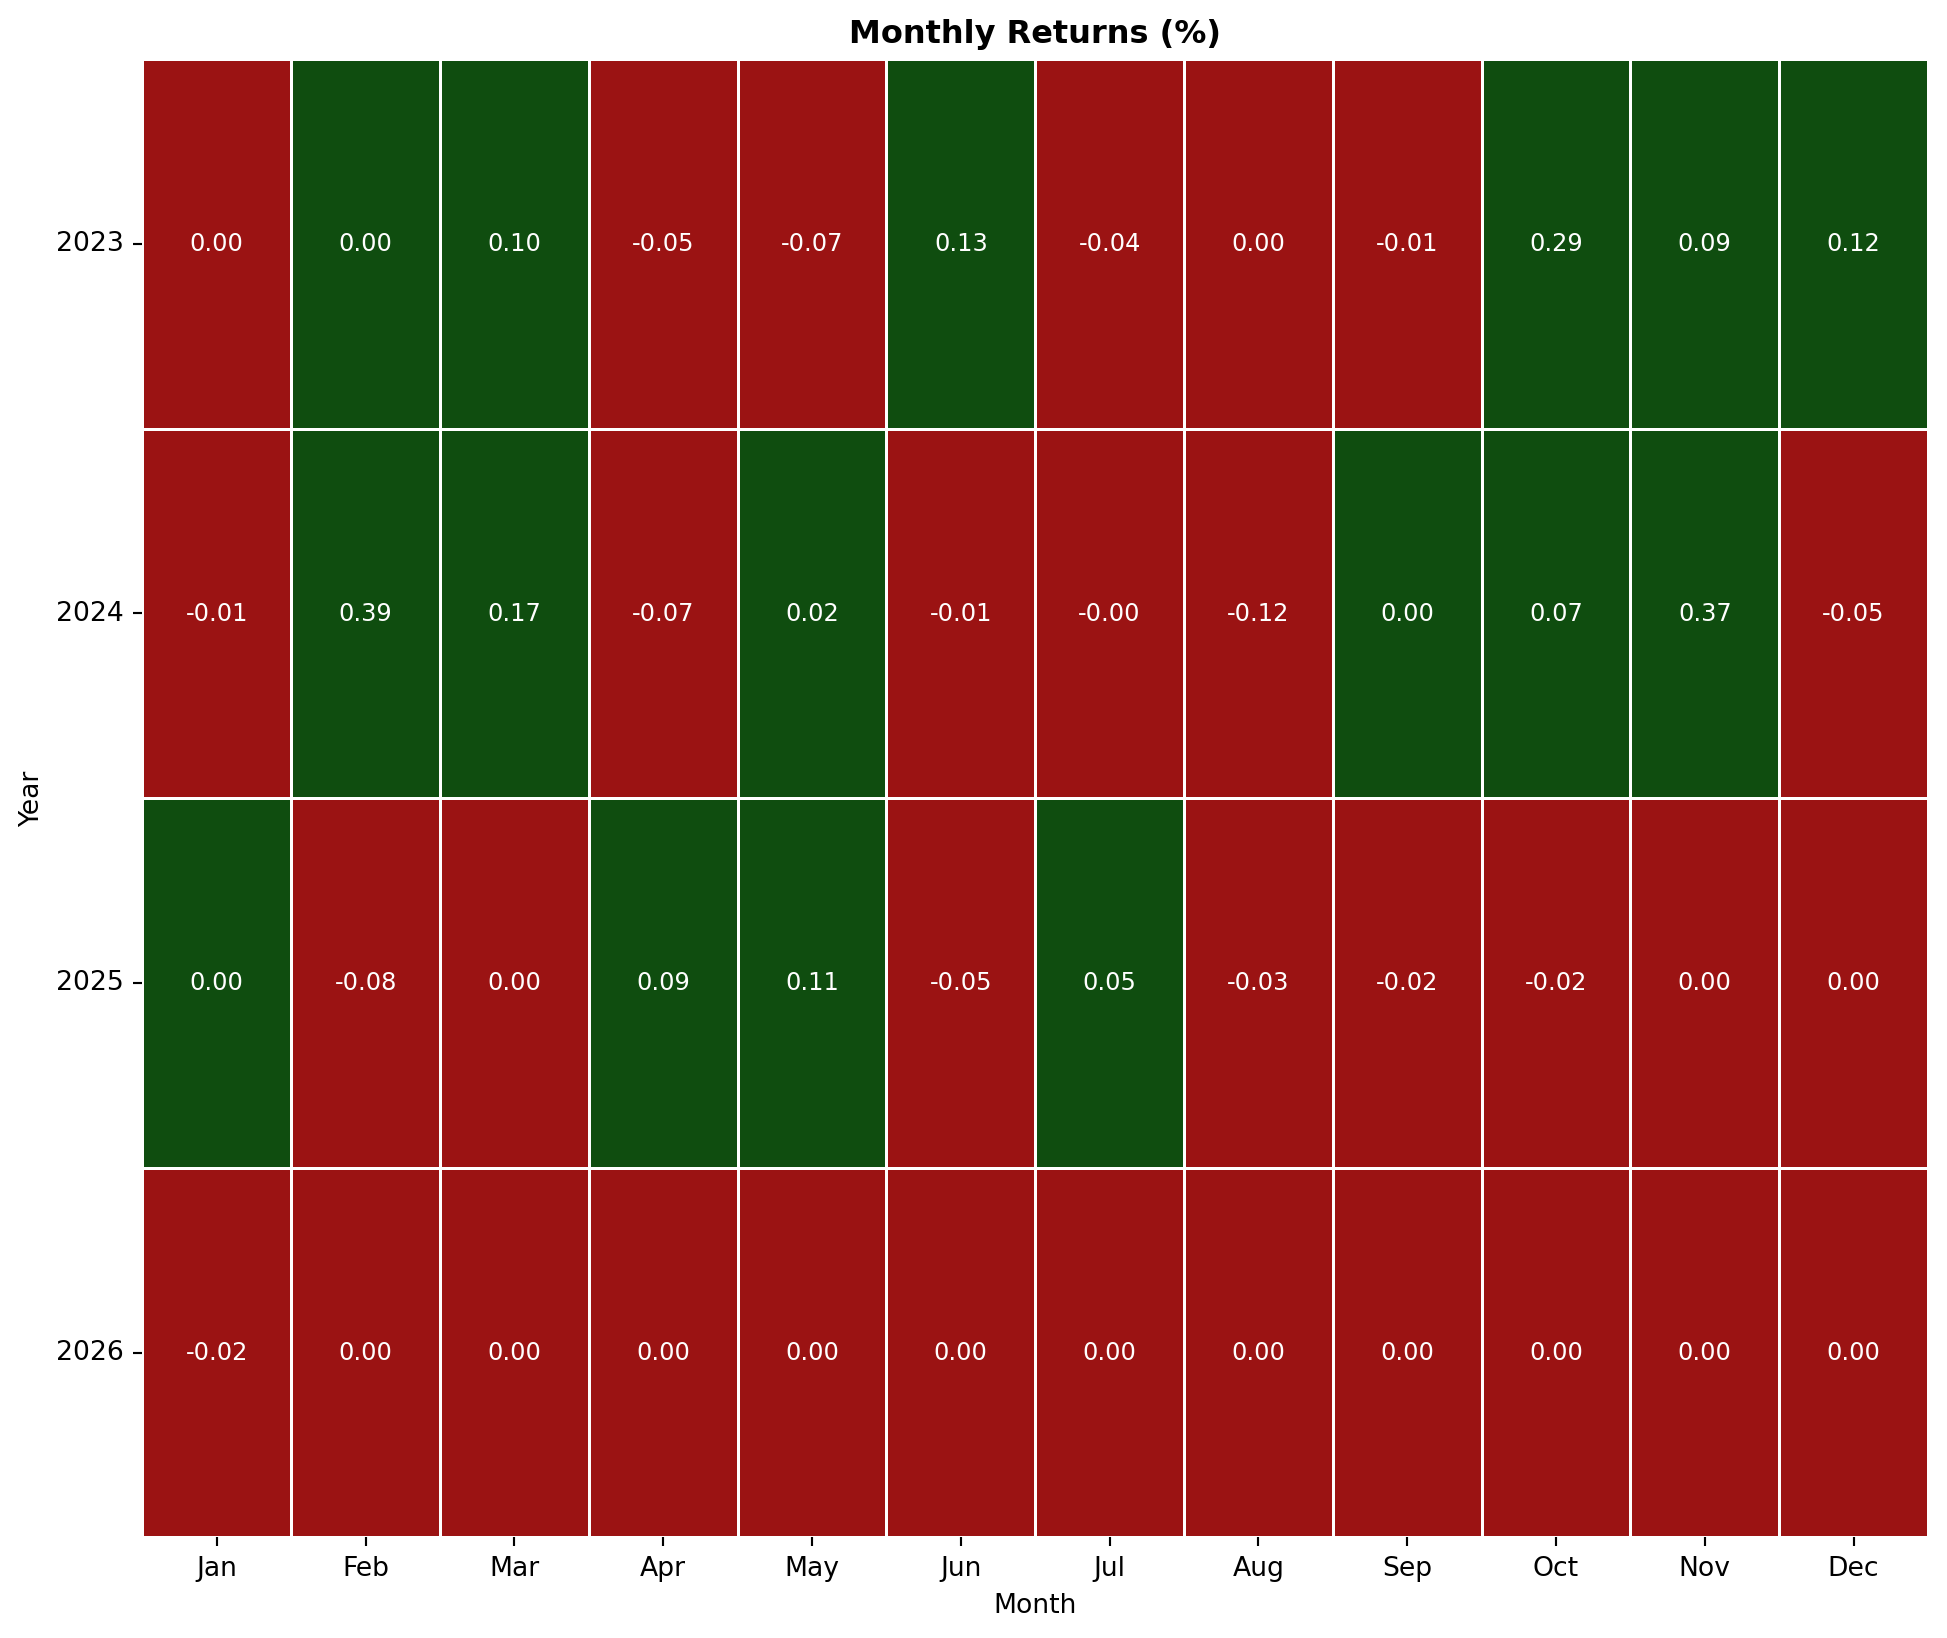

In [22]:
main.monthly_pos_neg_returns(os_result.returns)

##### Trades Analysis

In [23]:
os_result.trades

,symbol,open_date,close_date,bars_held,open_price,close_price,position_size,profit_loss,change_pct,trade_commission,cumulative_return,current_open_positions,why_exit
0,BTCUSDT,2023-01-07,2023-03-01,53,16952.12,23150.93,5.89,36493.61,36.57,472.19,136021.42,1,None
1,BTCUSDT,2023-03-02,2023-03-04,2,23647.02,22362.92,5.74,-7371.58,-5.43,528.26,128121.59,1,None
2,BTCUSDT,2023-03-14,2023-04-22,39,24201.77,27265.89,5.28,16188.80,12.66,543.84,143766.54,1,None
3,BTCUSDT,2023-04-28,2023-05-02,4,29481.01,28087.18,4.87,-6783.60,-4.73,560.35,136422.59,1,None
4,BTCUSDT,2023-05-03,2023-05-08,5,28680.49,28450.46,4.75,-1092.02,-0.80,542.42,134788.16,1,None
5,BTCUSDT,2023-05-29,2023-05-30,1,28075.59,27745.12,4.79,-1583.38,-1.18,534.91,132669.87,1,None
6,BTCUSDT,2023-06-20,2023-07-25,35,26841.66,29178.97,4.93,11529.51,8.71,552.68,143646.70,1,None
7,BTCUSDT,2023-09-19,2023-09-25,6,26760.85,26253.78,5.36,-2716.45,-1.89,568.01,140362.24,1,None
8,BTCUSDT,2023-09-26,2023-09-27,1,26294.76,26209.50,5.33,-454.21,-0.32,559.42,139348.61,1,None
9,BTCUSDT,2023-09-28,2024-01-13,107,26355.81,42799.45,5.28,86767.34,62.39,729.82,225386.14,1,None


At a first glance, it appears to be several trades lasting only 1 day, adding up unncessary Transaction Costs due to fakeouts.

In [24]:
tools.metrics_trades(os_result.trades, full_metrics=True)

,Trades Analysis
Nr trades,36.00
Win Rate %,36.11
Profit Factor,3.13
Avg. Win %,17.61
Avg. Loss %,-2.40
Reward/Risk,7.35
Expectancy %,4.83
Avg. Bars Held,18.00
Commissions,43979.81
Max Bars Held,107.00


In [25]:
tools.plot_trades_signals(df_test['BTCUSDT'][['Close', 'SMA40']], os_result.trades)

As stated previously, **there are consolidation periods that lead to several in and out trades in a short period of time, adding up transaction costs.**

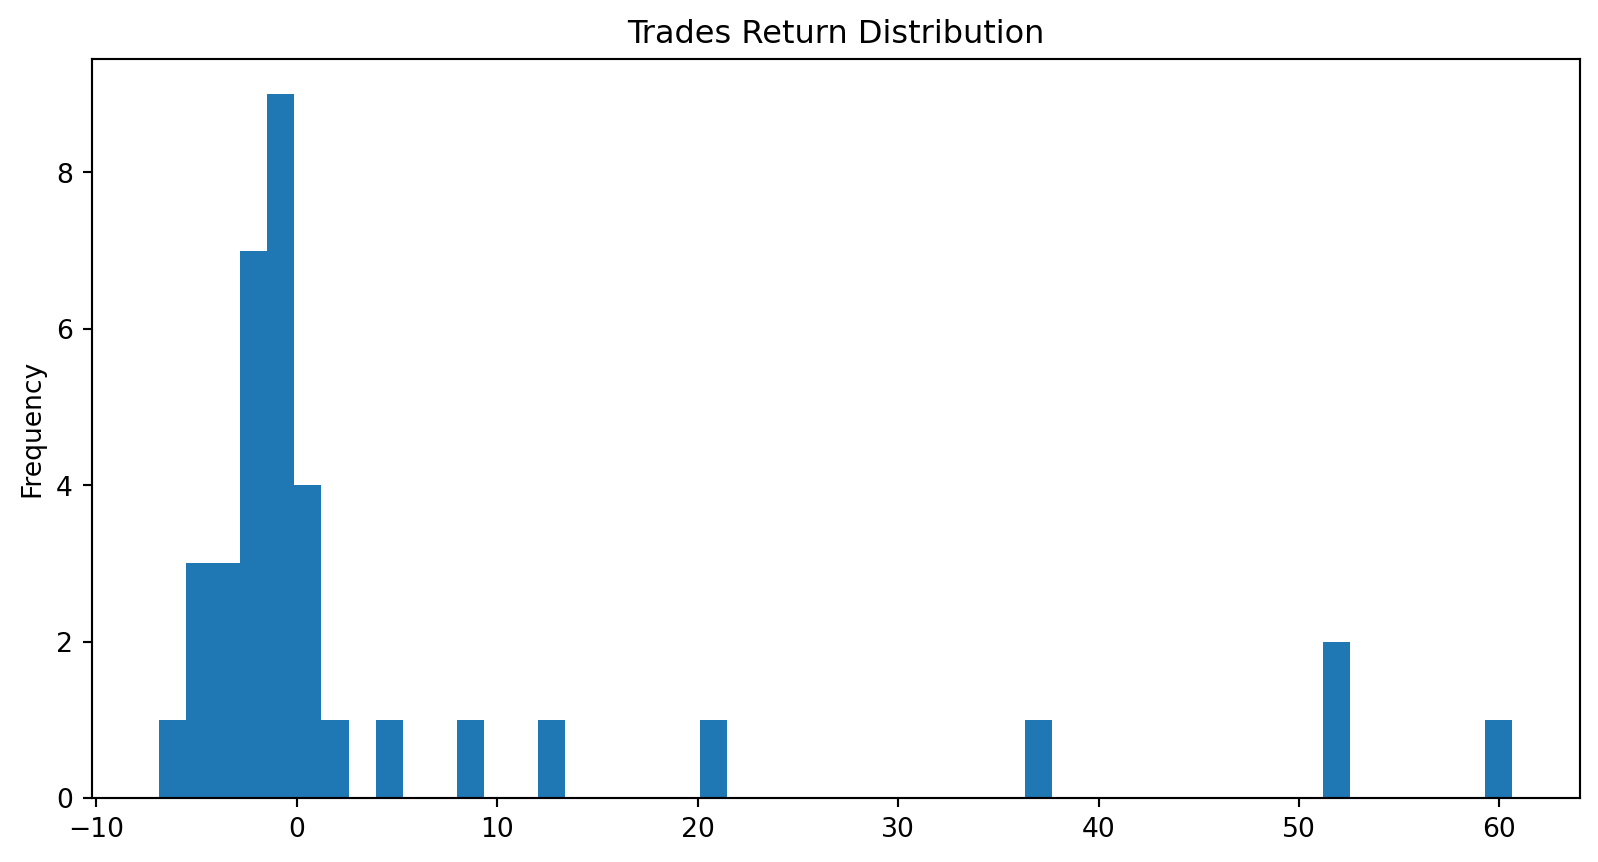

In [26]:
clipped_returns = main.cap_series(os_result.trades['change_pct'], percentile=0.005)
ax2 = clipped_returns.plot.hist(bins=50, title="Trades Return Distribution", figsize=(10, 5))

Strategy is working as intended, cutting losses short and letting profits run.

Avg. Bars Held: 18


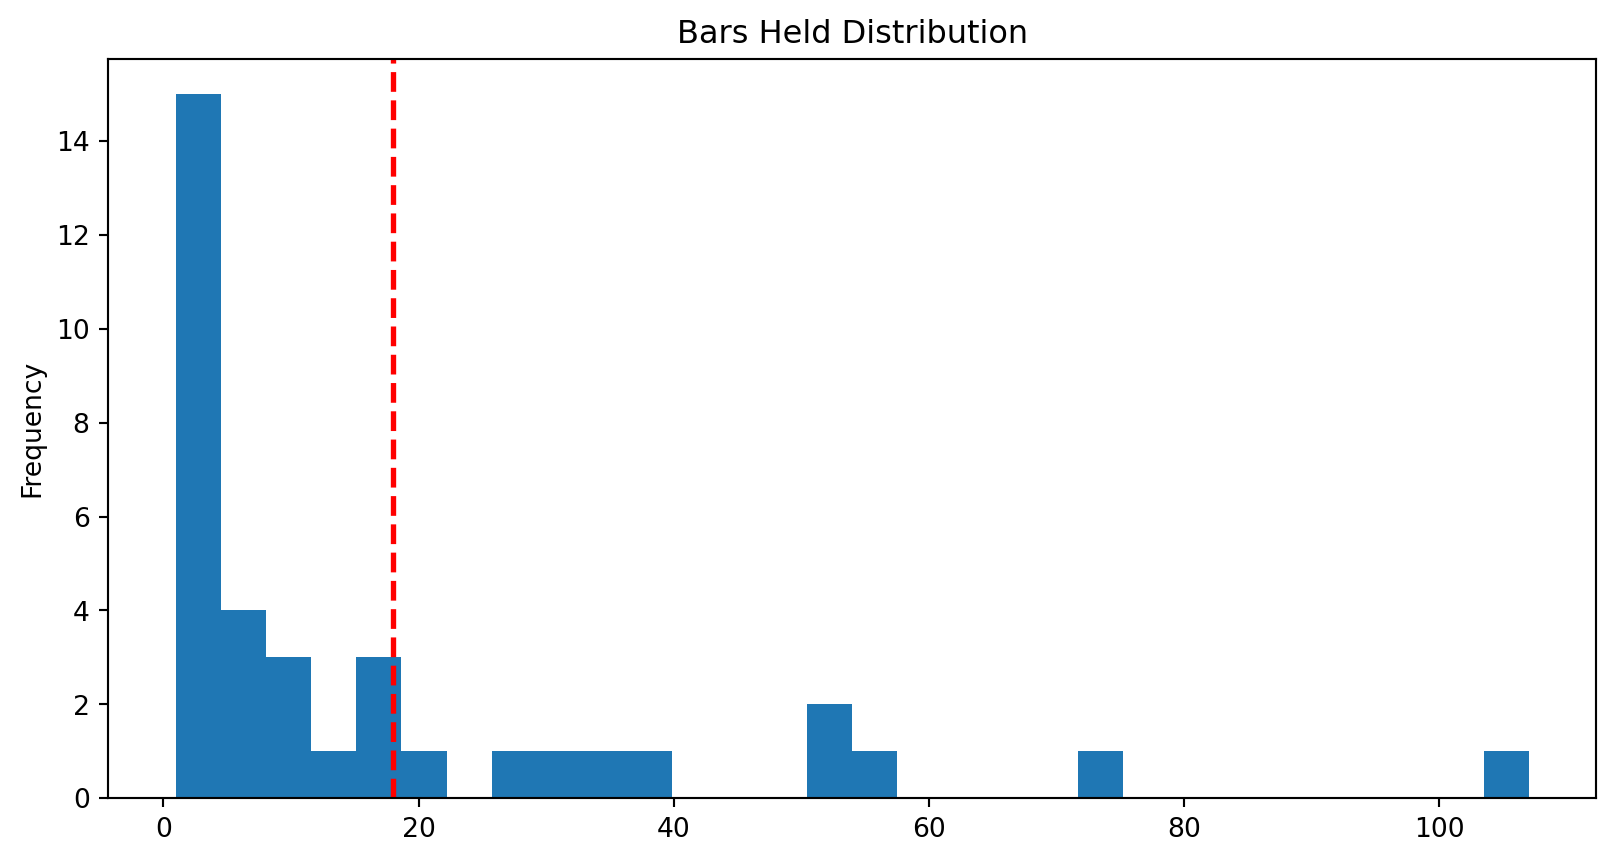

In [27]:
ax1 = os_result.trades['bars_held'].plot.hist(bins=30, title="Bars Held Distribution", figsize=(10, 5))
ax1.axvline(os_result.trades['bars_held'].mean(), color='red', linestyle='dashed', linewidth=2)
print("Avg. Bars Held:", int(os_result.trades['bars_held'].mean()))

Average trade lasted 18 days, there are several very short trades, this may not be ideal.

In [28]:
import plotly.express as px

ax2 = px.scatter(os_result.trades, 
                 x='bars_held', 
                 y='change_pct', 
                 width=900,
                 height=500, 
                 trendline="ols", 
                 trendline_color_override="black", 
                 title='Trade duration VS Trade Profit',
                 template='seaborn'
                 )

ax2.show()

Trend is clear, the longer the trade is the more profit it delivers.

##### Statistical Analysis

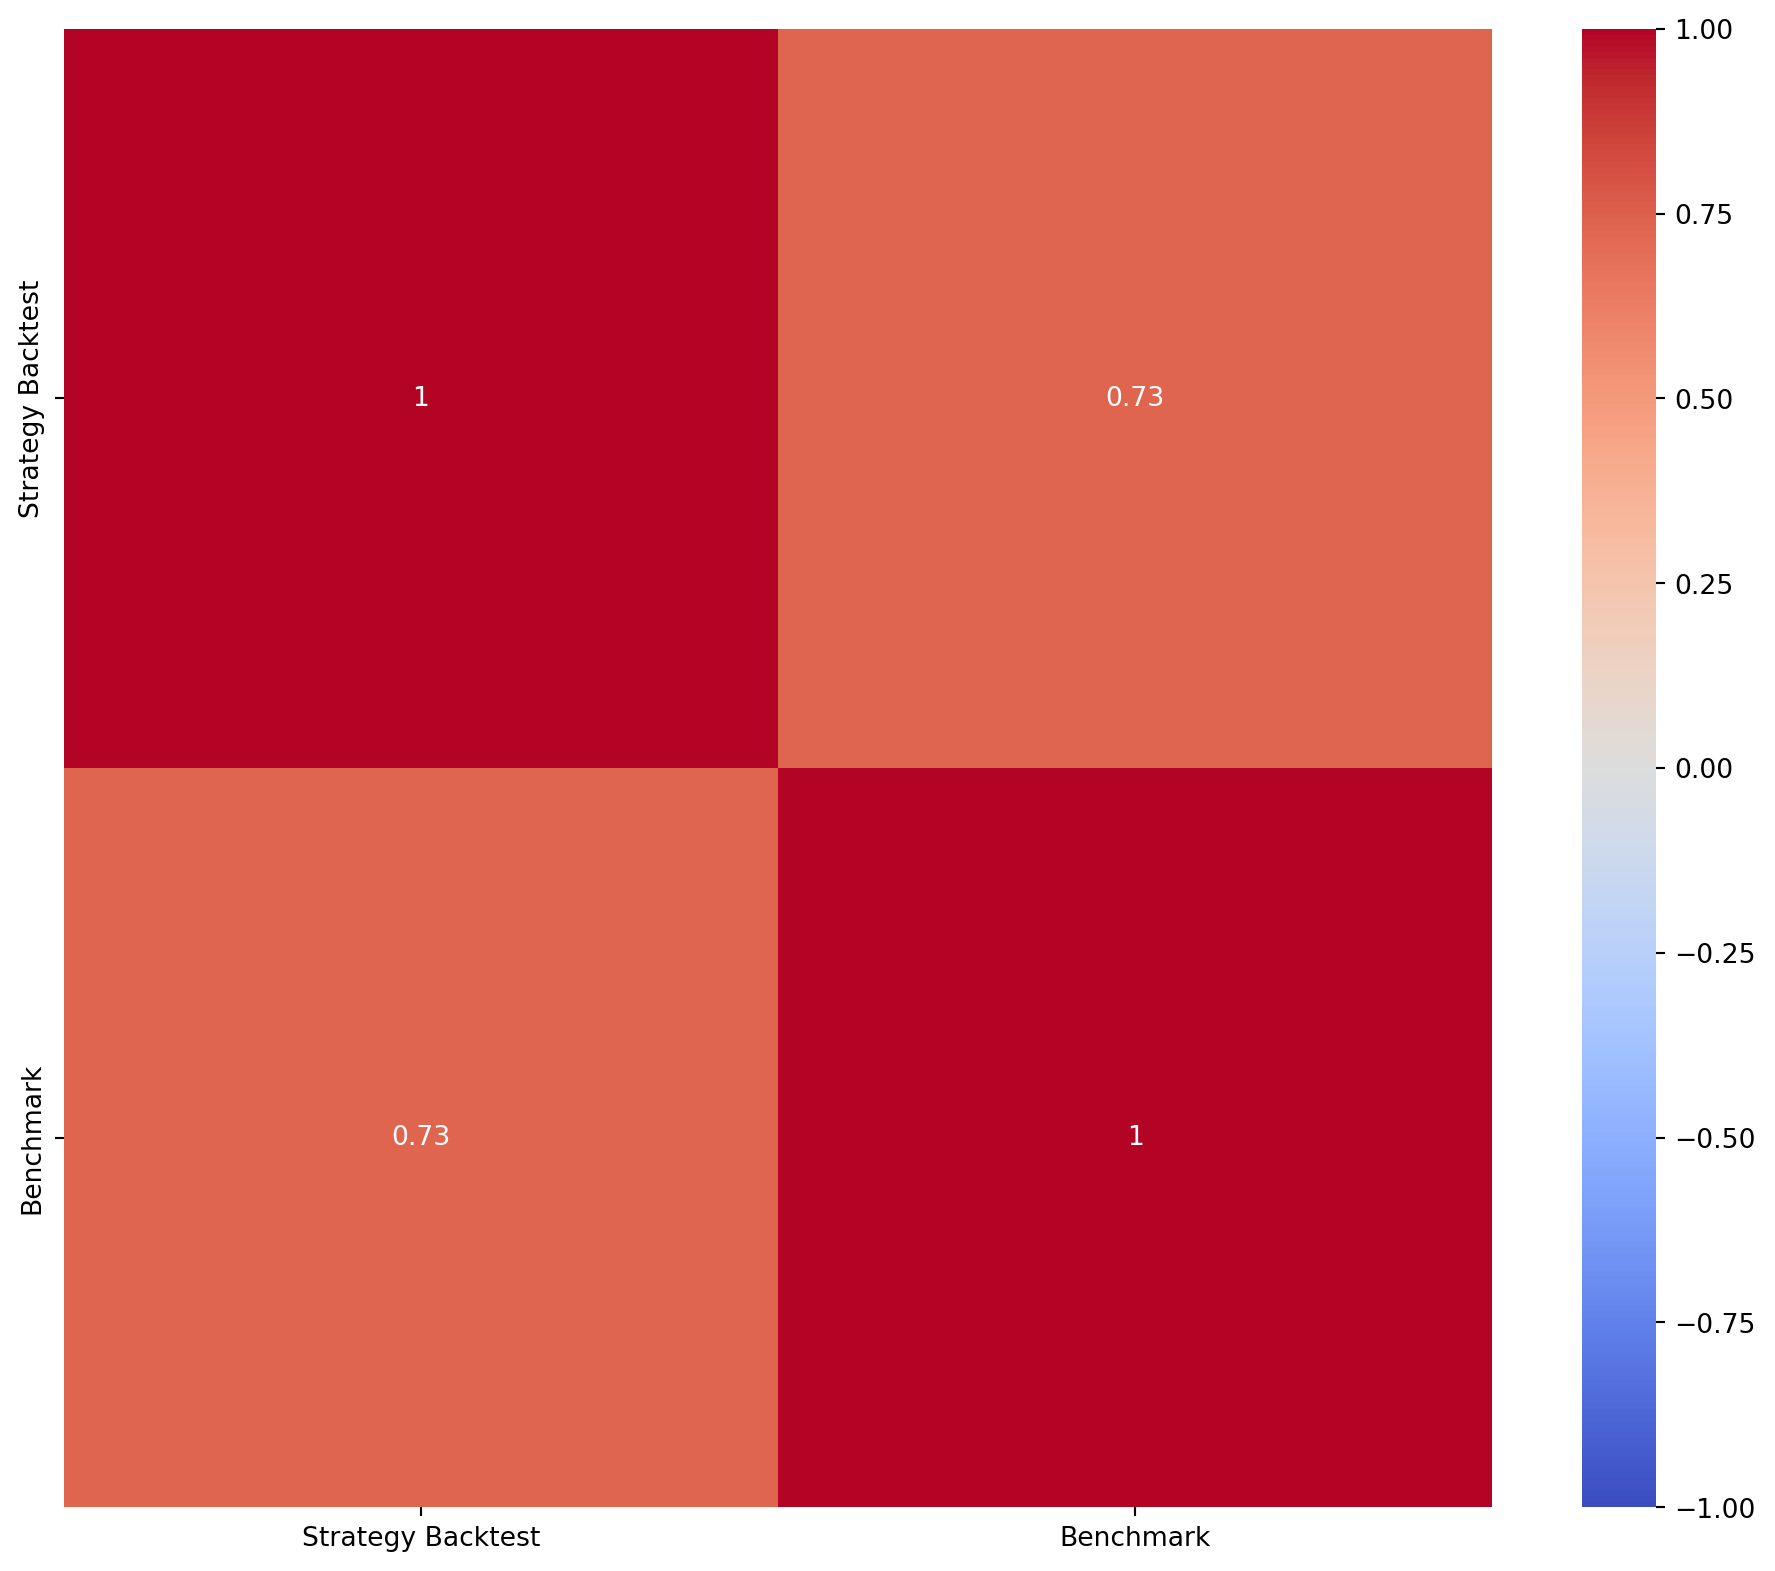

In [29]:
main.correlation_map(pd.concat([os_result.returns, os_result.benchmark], axis=1))

The tested Trend Following Strategy as a 0.7 correlation with Bitcoin Buy & Hold.

##### Is it significantly different from 0?

In [30]:
main.compute_t_test(os_result.returns)

P-value: 0.009881528305754408 Reject the null hypothesis (H₀). The strategy average return is significantly different from zero.


The out-of-sample returns exhibit a statistically significant positive mean with a p-value of 0.0099. This suggests that the strategy’s expected return is unlikely to be zero.

##### Does it pass Monte Carlo Permutation?

This will shuffle the given equity curve returns in random order, all output equity curves start and end at the same place, only the path will vary, to obtain Confidence Intervals for Max Draw Down Figures.

In [31]:
mcpyt = main.monte_carlo_permutation_yt(os_result.returns, nr_simulations=1000)

In [32]:
mcpyt.tail()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
2026-02-14,4.12,4.15,3.66,3.95,4.23,3.45,4.08,4.04,4.11,4.19,...,3.99,4.17,4.06,4.11,3.76,4.16,4.02,3.99,4.24,4.09
2026-02-15,4.18,4.10,3.70,3.97,4.23,3.54,4.06,4.04,4.09,4.19,...,4.06,4.03,4.06,4.07,3.93,4.22,4.12,3.87,4.26,4.01
2026-02-16,4.24,4.05,3.82,4.05,4.23,3.54,4.09,4.09,4.09,4.19,...,4.06,4.12,4.06,4.07,4.00,4.20,4.16,4.07,4.11,4.01
2026-02-17,4.24,4.07,3.92,4.05,4.09,3.73,4.09,4.09,4.09,4.09,...,4.01,4.14,4.09,4.07,4.00,4.23,4.16,4.09,4.09,3.98
2026-02-18,4.09,4.09,4.09,4.09,4.09,4.09,4.09,4.09,4.09,4.09,...,4.09,4.09,4.09,4.09,4.09,4.09,4.09,4.09,4.09,4.09


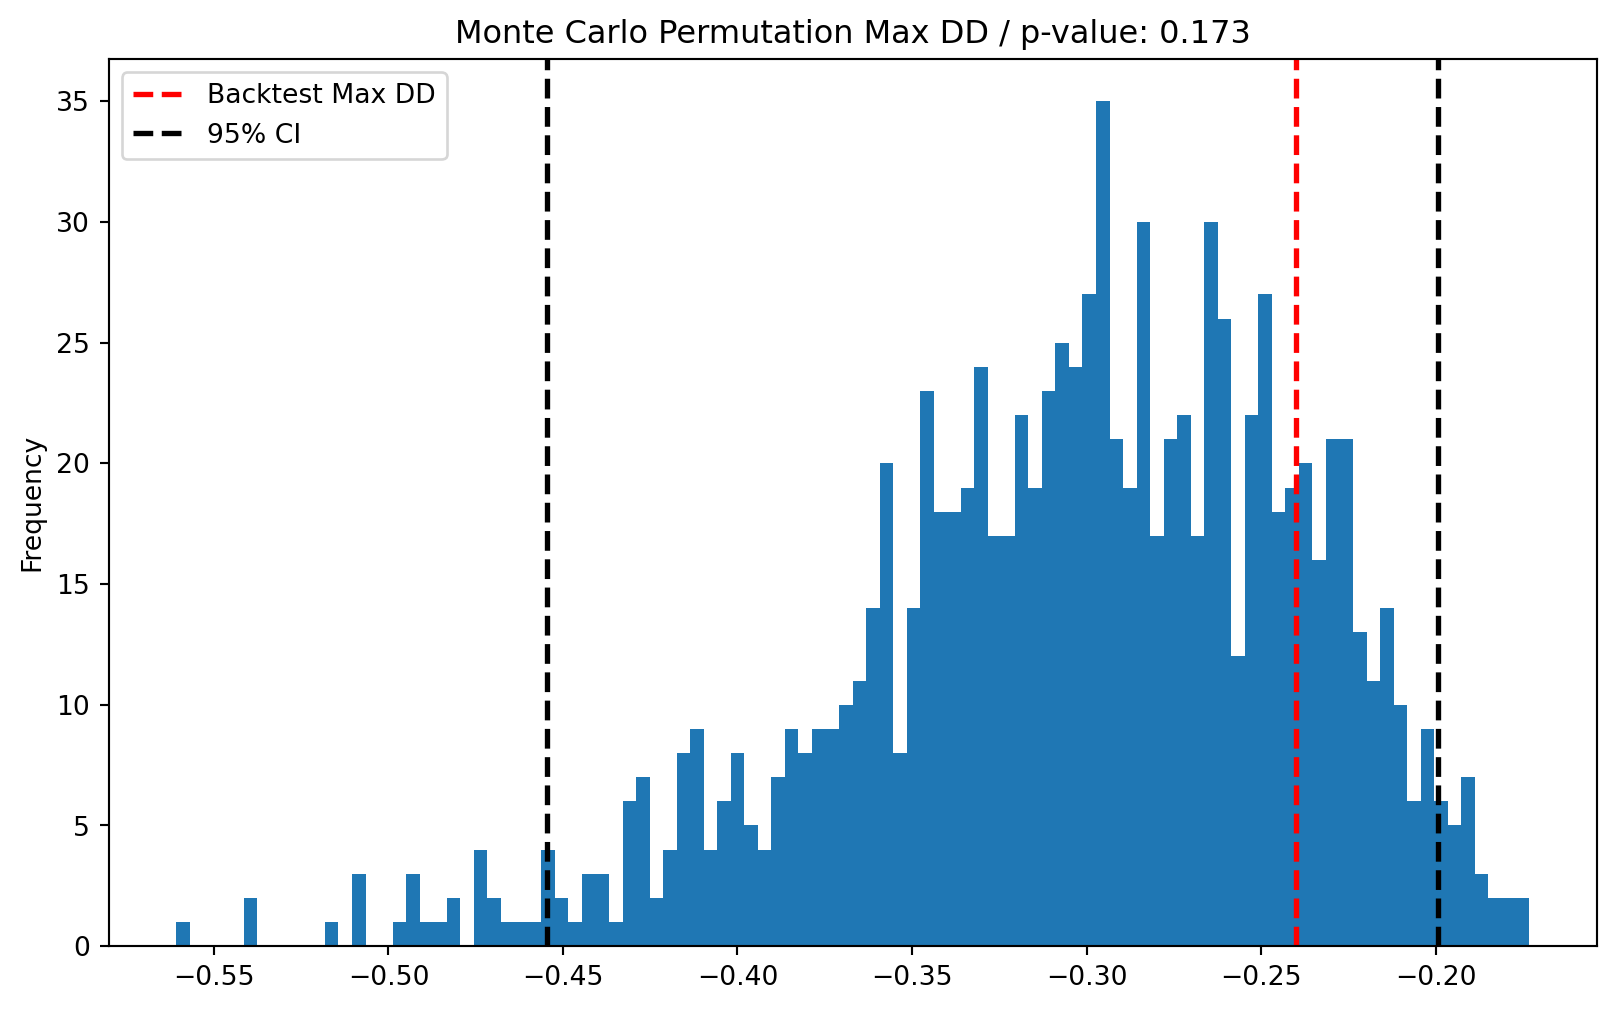

In [33]:
main.mcpyt_analysis(mcpyt, os_result.returns, ci=95)

The observed maximum drawdown lies within the 95% Monte Carlo confidence interval derived from return permutations. The p-value of 0.17 suggests that the realized drawdown is not statistically different from what would be expected under random ordering of returns. While the realized path exhibits somewhat smaller drawdowns than the average randomized path, the result does not provide strong statistical evidence that the strategy benefits from favorable return sequencing.

## Final Thoughts

The backtests indicate that even a minimal rule-based approach can produce attractive risk-adjusted performance in a strongly trending asset such as Bitcoin, aligning with the original system objectives of high CAGR and acceptable drawdowns.

A future suggestion improvement is to look at reducing trade fakeouts, and analyzing several assets.